<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
try:
    import datasets
    print('Datasets already installed.')
except ImportError:
    !pip install datasets
    print('Datasets installed successfully.')

Datasets already installed.


Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Фиксация начального значения для обеспечения воспроизводимости результатов

In [5]:
import random
import os

def set_seed(seed=42, torch_use_deterministic_algorithms=False):
    # 1. Стандартный Python и NumPy (Всегда безопасно)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. PyTorch для процессора (CPU)
    torch.manual_seed(seed)

    # 3. PyTorch для видеокарты (CUDA)
    if torch.cuda.is_available():
        print(f'{torch.cuda.get_device_name(0)=}')
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        if torch_use_deterministic_algorithms:
            # Настройки cuDNN для полной воспроизводимости
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        else:
            # Разрешаем cuDNN выбирать самые быстрые алгоритмы под вашу L4
            torch.backends.cudnn.deterministic = False
            torch.backends.cudnn.benchmark = True

        # Принудительное использование детерминированных алгоритмов (может быть медленно)
        torch.use_deterministic_algorithms(torch_use_deterministic_algorithms)

    print(f'Seed установлен: {seed}. Доступность CUDA: {torch.cuda.is_available()}')


random_seed = 19632109
set_seed(random_seed)


torch.cuda.get_device_name(0)='NVIDIA L4'
Seed установлен: 19632109. Доступность CUDA: True


## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [6]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходимо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предложения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

**Мой Комментарий**

Создаю `sentences` не как список предложений, а список токенизированнных предложений, то есть список списков слов, чтобы не делать токенизацию ещё раз в `WordDataset`. Одновременно заполняю счетчик слов.

In [7]:
sentences = []
word_threshold = 32

words = Counter()

# Получить отдельные предложения и поместить их в sentences
for text in tqdm(dataset['train']['text']):
    # Pазбиваем текст на предложения
    for sent in sent_tokenize(text, language='english'):
      # Переводим предложение в нижний регистр и разбиваем на слова.
      # Предложение уже результат токенизации, поэтому делаем preserve_line=True.
      # Иначе предложение будет токенизировано ещё раз и при этом возможны неточноCти,
      # например 'etc.' перейдёт в 'etc' и '.'.
      words_in_sent = word_tokenize(sent.lower(), language='english', preserve_line=True)
      # Если количество слов меньше word_threshold, то добавляем предложение в список а также слова в счетчик
      if len(words_in_sent) < word_threshold:
        sentences.append(words_in_sent)
        words.update(words_in_sent)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [8]:
print("Всего предложений:", len(sentences))

Всего предложений: 198802


Посчитаем для каждого слова его встречаемость.

**Мой Комментарий**

 Расчёт встречаемости уже сделан при подготовке списка предложений.

In [9]:
# words = Counter()

# Расчет встречаемости слов

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [10]:
#vocab = set()
vocab_size = 40000

# Наполнение словаря
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>']).union(word for word, count in words.most_common(vocab_size))

In [11]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [12]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [13]:
word2ind = {word: i for i, word in enumerate(vocab)}
ind2word = {i: word for word, i in word2ind.items()}

**Мой Комментарий**

Переделываю конструктор класса `WordDataset` так, чтобы делать обработку всего текста сразу в конструкторе. Это ускоряет вычисления.

In [14]:
class WordDataset:
    def __init__(self, sentences):
        # self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']
        # Обработаем все списки сразу в конструкторе для ускорения.
        # Здесь sentences - это не список предложений, а список токенизированнных предложений,
        # то есть список списков слов.
        self.data = []
        for sentence in sentences:
          self.data.append([self.bos_id] + [word2ind.get(word, self.unk_id) for word in sentence] + [self.eos_id])

    def __getitem__(self, idx: int) -> List[int]:
        #tokenized_sentence = []
        # Допишите код здесь

        #return tokenized_sentence
        # Вернём уже обработанные предложения
        return self.data[idx]

    def __len__(self) -> int:
        return len(self.data)

In [15]:
from typing import Dict

def collate_fn_with_padding(
    # input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> Dict[str, torch.Tensor]:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

**Мой Комментарий**

В клетке было

`train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)`

`eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)`

Считаю, что это ошибка. Получается, что первая eval_sentences игнорируется. Валидационная и тестовая выборки получаются очень большими и могут пересекаться с тренировочной. Изменяю на типичное 80%, 10%, 10% деление.

In [16]:
# train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
# eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)
train_sentences, temp_sentences = train_test_split(sentences, test_size=0.2, random_state=random_seed)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5, random_state=random_seed)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [17]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [18]:
def train_model(model, train_dataloader, val_dataloader, test_dataloader, optimizer, criterion, num_epoch=5, desc_prefix=''):
    train_losses = []
    train_ppls = []
    val_ppls = []

    for epoch in range(num_epoch):
        model.train()
        epoch_losses = []
        epoch_ppls = [] # Список для перплексии каждого батча (аналогично evaluate)

        # Фаза обучения
        for batch in tqdm(train_dataloader, desc=f'{desc_prefix}Эпоха {epoch}'):
            optimizer.zero_grad()

            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())

            loss.backward()
            optimizer.step()

            # Сохраняем значения для расчета метрик
            epoch_losses.append(loss.item())
            # Считаем перплексию батча через exp(loss), как в функции evaluate
            epoch_ppls.append(torch.exp(loss).item())

        # Расчет средних метрик за эпоху
        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        # Средняя перплексия по всем батчам (соответствует логике evaluate)
        avg_train_ppl = sum(epoch_ppls) / len(epoch_ppls)

        # Фаза валидации
        val_ppl = evaluate(model, criterion, val_dataloader)

        # Сохранение истории
        train_losses.append(avg_train_loss)
        train_ppls.append(avg_train_ppl)
        val_ppls.append(val_ppl)

        print(f'{desc_prefix}Эпоха {epoch}: Train Loss {avg_train_loss:.4f} | '
              f'Train PPL {avg_train_ppl:.4f} | Val PPL {val_ppl:.4f}')

    # Финальная проверка на тестовом наборе
    test_ppl = evaluate(model, criterion, test_dataloader)
    print(f'\n{desc_prefix}Итоговая перплексия на Test set: {test_ppl:.4f}')

    return train_losses, train_ppls, val_ppls, test_ppl

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

**Мой Комментарий**

Создаём модель с LSTM и cлоем исключения после embedding  и после LSTM  для борьбы с переобучением.

Определяем функции для визуализации.

In [19]:
class LanguageModelLSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, dropout: float = 0.3,
                 num_layers: int = 1, bidirectional: bool = False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.dropout_embed = nn.Dropout(p=dropout)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, num_layers=num_layers,
                           bidirectional=bidirectional, batch_first=True)
        self.non_lin = nn.Tanh()
        num_directions = 2 if bidirectional else 1
        self.linear = nn.Linear(hidden_dim * num_directions, hidden_dim)
        self.dropout_final = nn.Dropout(p=dropout)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout_embed(embeddings)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(output)  # [batch_size, seq_len, hidden_dim * num_directions]
        output = self.dropout_final(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_dynamics(losses, model_name='LSTM'):
    """
    Визуализация динамики функции потерь.

    Args:
        losses (list/array): Список значений потерь по эпохам.
        model_name (str): Название модели для заголовка графика.
    """
    plt.figure(figsize=(10, 10))

    # Построение графика
    plt.plot(np.arange(len(losses)), losses, color='g', marker='o')

    # Оформление
    plt.title(f'{model_name}: Динамика функции потерь')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение потерь')

    # Сетка с прозрачностью
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()

# Пример вызова:
# plot_loss_dynamics(train_losses_LSTM_Uni_256_1, model_name='LSTM Уни 256*1')

In [21]:
def plot_perplexity_metrics(val_perplexities, train_perplexities, model_name='LSTM'):
    """
    Визуализация метрик перплексии и разрыва обобщающей способности (Generalization Gap).

    Args:
        val_perplexities (list/array): Значения перплексии на валидационной выборке.
        train_perplexities (list/array): Значения перплексии на тренировочной выборке.
        model_name (str): Название модели для заголовков графиков.
    """
    epochs = np.arange(len(val_perplexities))
    train_ppl = np.array(train_perplexities)
    val_ppl = np.array(val_perplexities)
    gap = val_ppl - train_ppl  # Вычисляем разрыв (разница между валидацией и обучением)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # --- Верхний график: Исходные показатели перплексии ---
    ax1.plot(epochs, val_ppl, label='Валидационная PPL', color='g', marker='o')
    ax1.plot(epochs, train_ppl, label='Тренировочная PPL', color='b', marker='s')
    ax1.set_title(f'{model_name}: Сравнение перплексии (PPL): Обучение vs Валидация')
    ax1.set_ylabel('Перплексия (PPL)')
    ax1.legend()
    ax1.grid(True, alpha=0.5)

    # Выделяем точку начала расхождения (переобучения)
    overfit_mask = val_ppl > train_ppl
    if any(overfit_mask):
        # Находим первый индекс, где валидация стала хуже обучения
        switch_idx = np.where(overfit_mask)[0][0]
        ax1.axvline(x=switch_idx, color='red', linestyle='--', alpha=0.5, label='Точка расхождения')
        ax1.legend()

    # --- Нижний график: Разрыв (Generalization Gap) ---
    ax2.plot(epochs, gap, color='purple', linewidth=2, label='Разрыв (Валид. - Обуч.)')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3) # Линия нуля
    ax2.fill_between(epochs, gap, 0, where=(gap > 0), color='purple', alpha=0.1)

    ax2.set_title(f'{model_name}: Рост разрыва обобщающей способности (Generalization Gap)')
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Разница (в единицах PPL)')
    ax2.legend()
    ax2.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

# Пример вызова:
# plot_perplexity_metrics(val_ppls_LSTM_Uni_256_1, train_ppls_LSTM_Uni_256_1, model_name='LSTM Уни 256*1')

**Мой Комментарий**

Критерий - кросс-энтропия - не изменяется.

In [22]:
cross_entropy_criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

**Мой Комментарий**

Применяем `dropout` = 0.3 в модели, а также `lr` = 5e-4 и `weight_decay` = 1 e-5 при оптимизации для борьбы с переобучением.

In [23]:
model_LSTM_Uni_256_1 = LanguageModelLSTM(hidden_dim=256, vocab_size=len(vocab), dropout=0.3).to(device)
if torch.cuda.device_count() > 1:
    print(f'Используем {torch.cuda.device_count()} GPU для обучения!')
    model_LSTM_Uni_256_1 = nn.DataParallel(model_LSTM_Uni_256_1)
optimizer_LSTM_Uni_256_1 = torch.optim.Adam(model_LSTM_Uni_256_1.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses_LSTM_Uni_256_1 = None
train_ppls_LSTM_Uni_256_1 = None
val_ppls_LSTM_Uni_256_1 = None
test_ppl_LSTM_Uni_256_1 = None
%time train_losses_LSTM_Uni_256_1, train_ppls_LSTM_Uni_256_1, val_ppls_LSTM_Uni_256_1, test_ppl_LSTM_Uni_256_1 = \
    train_model(model_LSTM_Uni_256_1, train_dataloader, eval_dataloader, test_dataloader,\
                optimizer_LSTM_Uni_256_1, cross_entropy_criterion, num_epoch=5, desc_prefix='LSTM Уни 256*1: ')

LSTM Уни 256*1: Эпоха 0:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*1: Эпоха 0: Train Loss 5.8095 | Train PPL 873.1326 | Val PPL 239.6384


LSTM Уни 256*1: Эпоха 1:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*1: Эпоха 1: Train Loss 5.1828 | Train PPL 179.2102 | Val PPL 193.0004


LSTM Уни 256*1: Эпоха 2:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*1: Эпоха 2: Train Loss 5.0021 | Train PPL 149.4029 | Val PPL 169.4462


LSTM Уни 256*1: Эпоха 3:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*1: Эпоха 3: Train Loss 4.8802 | Train PPL 132.2151 | Val PPL 153.2135


LSTM Уни 256*1: Эпоха 4:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*1: Эпоха 4: Train Loss 4.7901 | Train PPL 120.7992 | Val PPL 143.3387

LSTM Уни 256*1: Итоговая перплексия на Test set: 142.1171
CPU times: user 5min 48s, sys: 1.16 s, total: 5min 49s
Wall time: 5min 48s


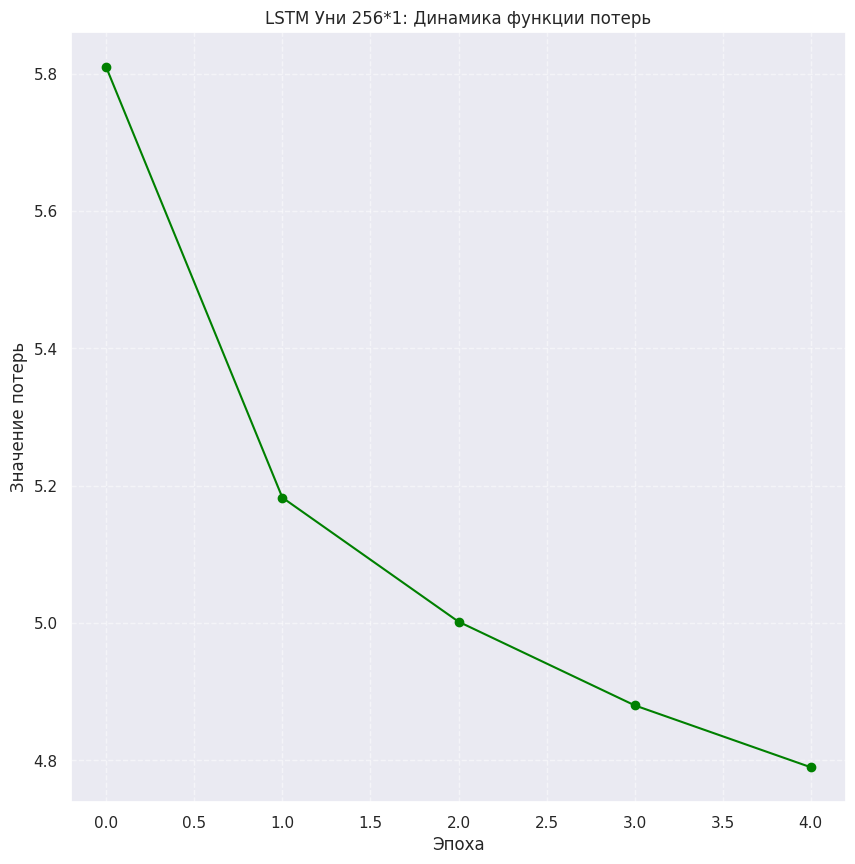

In [24]:
plot_loss_dynamics(train_losses_LSTM_Uni_256_1, model_name='LSTM Уни 256*1')

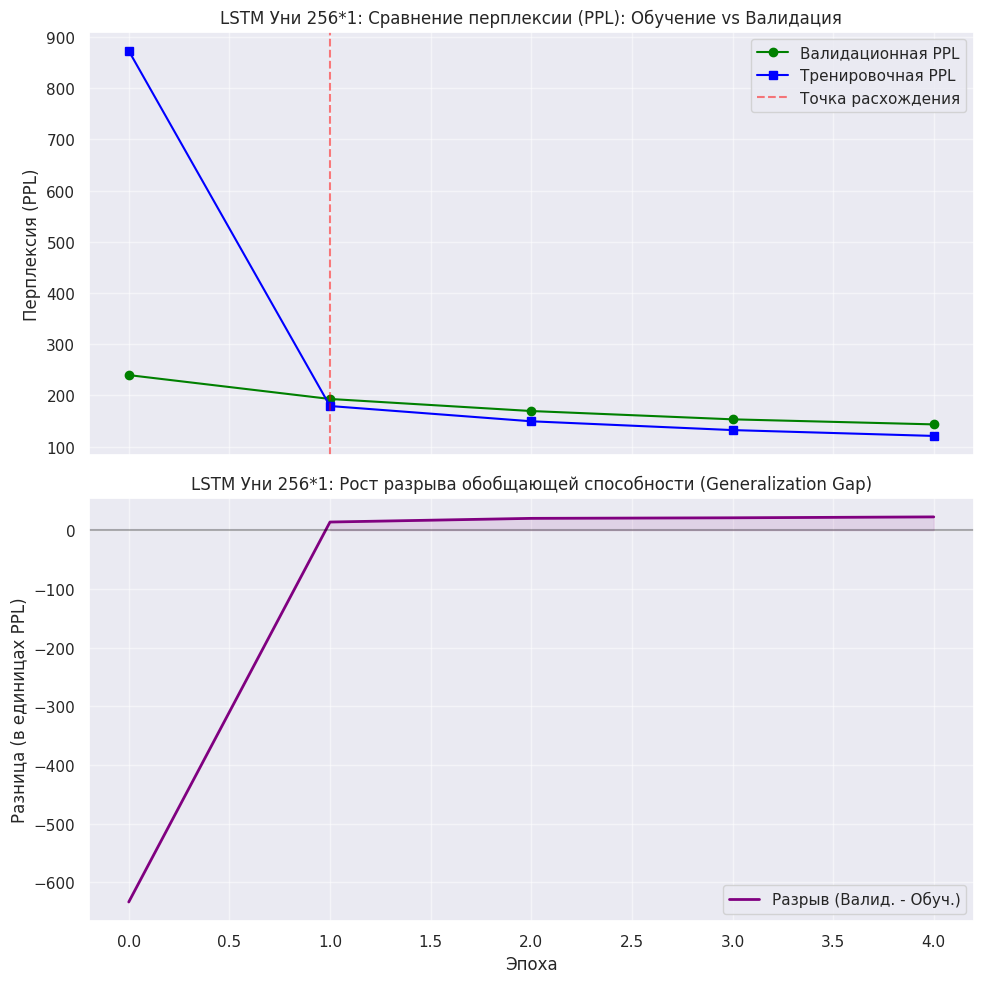

In [25]:
plot_perplexity_metrics(val_ppls_LSTM_Uni_256_1, train_ppls_LSTM_Uni_256_1, model_name='LSTM Уни 256*1')

In [26]:
model_LSTM_Uni_512_1 = LanguageModelLSTM(hidden_dim=512, vocab_size=len(vocab), dropout=0.3).to(device)
if torch.cuda.device_count() > 1:
    print(f'Используем {torch.cuda.device_count()} GPU для обучения!')
    model_LSTM_Uni_512_1 = nn.DataParallel(model_LSTM_Uni_512_1)
optimizer_LSTM_Uni_512_1 = torch.optim.Adam(model_LSTM_Uni_512_1.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses_LSTM_Uni_512_1 = None
train_ppls_LSTM_Uni_512_1 = None
val_ppls_LSTM_Uni_512_1 = None
test_ppl_LSTM_Uni_512_1 = None
%time train_losses_LSTM_Uni_512_1, train_ppls_LSTM_Uni_512_1, val_ppls_LSTM_Uni_512_1, test_ppl_LSTM_Uni_512_1 = \
    train_model(model_LSTM_Uni_512_1, train_dataloader, eval_dataloader, test_dataloader,\
                optimizer_LSTM_Uni_512_1, cross_entropy_criterion, num_epoch=5, desc_prefix='LSTM Уни 512*1: ')

LSTM Уни 512*1: Эпоха 0:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1: Эпоха 0: Train Loss 5.4902 | Train PPL 545.2713 | Val PPL 176.0767


LSTM Уни 512*1: Эпоха 1:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1: Эпоха 1: Train Loss 4.9261 | Train PPL 138.6892 | Val PPL 143.0132


LSTM Уни 512*1: Эпоха 2:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1: Эпоха 2: Train Loss 4.7421 | Train PPL 115.2252 | Val PPL 128.1484


LSTM Уни 512*1: Эпоха 3:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1: Эпоха 3: Train Loss 4.6144 | Train PPL 101.3744 | Val PPL 118.6217


LSTM Уни 512*1: Эпоха 4:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1: Эпоха 4: Train Loss 4.5142 | Train PPL 91.6896 | Val PPL 111.0223

LSTM Уни 512*1: Итоговая перплексия на Test set: 110.3915
CPU times: user 9min 13s, sys: 1.02 s, total: 9min 14s
Wall time: 9min 13s


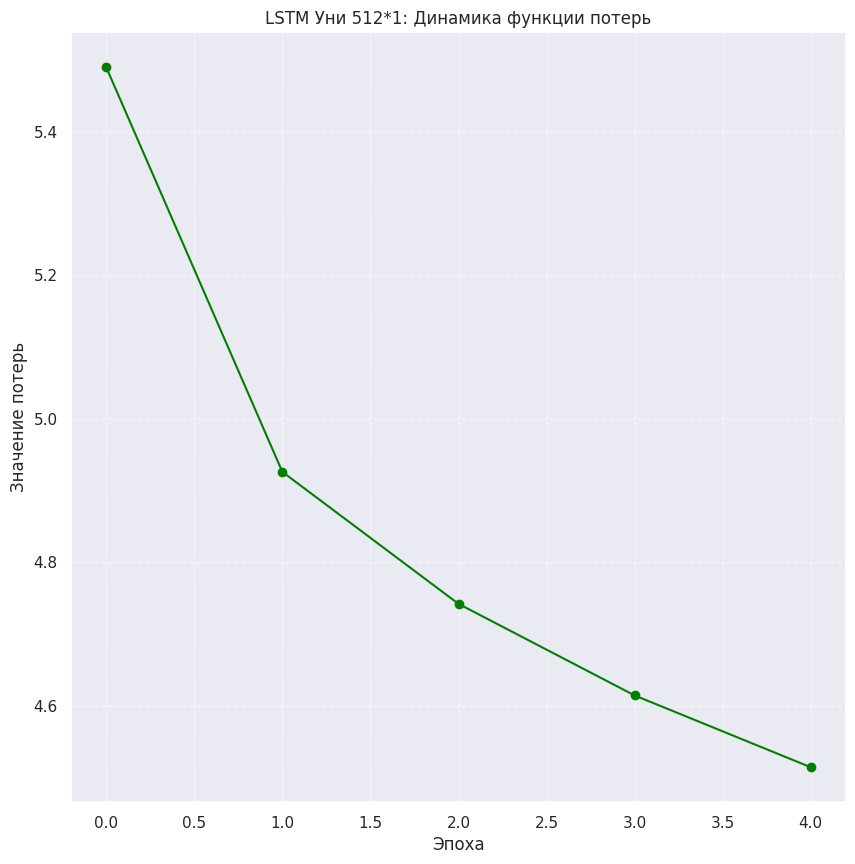

In [27]:
plot_loss_dynamics(train_losses_LSTM_Uni_512_1, model_name='LSTM Уни 512*1')

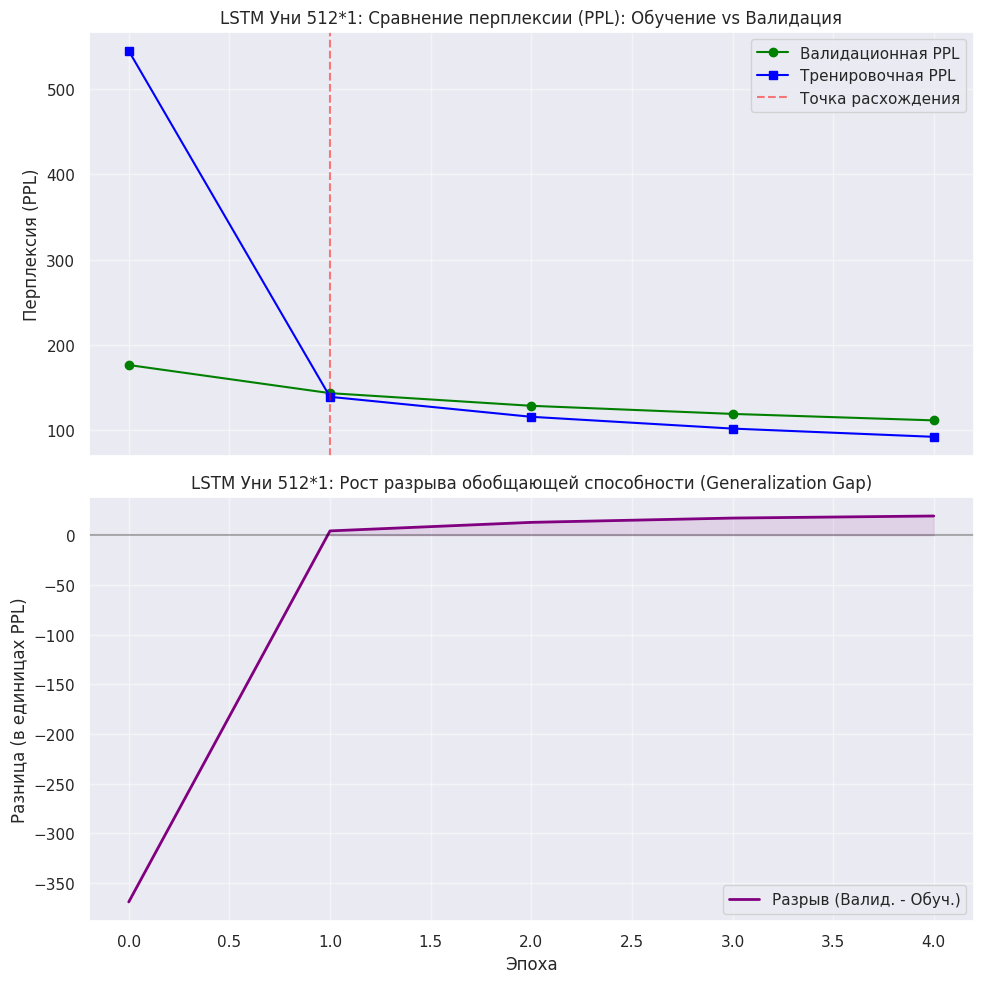

In [28]:
plot_perplexity_metrics(val_ppls_LSTM_Uni_512_1, train_ppls_LSTM_Uni_512_1, model_name='LSTM Уни 512*1')

In [29]:
model_LSTM_Uni_256_2 = LanguageModelLSTM(hidden_dim=256, vocab_size=len(vocab), dropout=0.3, num_layers=2).to(device)
if torch.cuda.device_count() > 1:
    print(f'Используем {torch.cuda.device_count()} GPU для обучения!')
    model_LSTM_Uni_256_2 = nn.DataParallel(model_LSTM_Uni_256_2)
optimizer_LSTM_Uni_256_2 = torch.optim.Adam(model_LSTM_Uni_256_2.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses_LSTM_Uni_256_2 = None
train_ppls_LSTM_Uni_256_2 = None
val_ppls_LSTM_Uni_256_2 = None
test_ppl_LSTM_Uni_256_2 = None
%time train_losses_LSTM_Uni_256_2, train_ppls_LSTM_Uni_256_2, val_ppls_LSTM_Uni_256_2, test_ppl_LSTM_Uni_256_2 = \
    train_model(model_LSTM_Uni_256_2, train_dataloader, eval_dataloader, test_dataloader,\
                optimizer_LSTM_Uni_256_2, cross_entropy_criterion, num_epoch=5, desc_prefix='LSTM Уни 256*2: ')

LSTM Уни 256*2: Эпоха 0:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*2: Эпоха 0: Train Loss 6.1682 | Train PPL 898.4868 | Val PPL 325.6997


LSTM Уни 256*2: Эпоха 1:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*2: Эпоха 1: Train Loss 5.3675 | Train PPL 216.0655 | Val PPL 215.6957


LSTM Уни 256*2: Эпоха 2:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*2: Эпоха 2: Train Loss 5.1275 | Train PPL 169.4045 | Val PPL 184.6291


LSTM Уни 256*2: Эпоха 3:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*2: Эпоха 3: Train Loss 4.9814 | Train PPL 146.3039 | Val PPL 166.3635


LSTM Уни 256*2: Эпоха 4:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 256*2: Эпоха 4: Train Loss 4.8730 | Train PPL 131.2326 | Val PPL 153.8242

LSTM Уни 256*2: Итоговая перплексия на Test set: 152.7895
CPU times: user 5min 58s, sys: 918 ms, total: 5min 59s
Wall time: 5min 58s


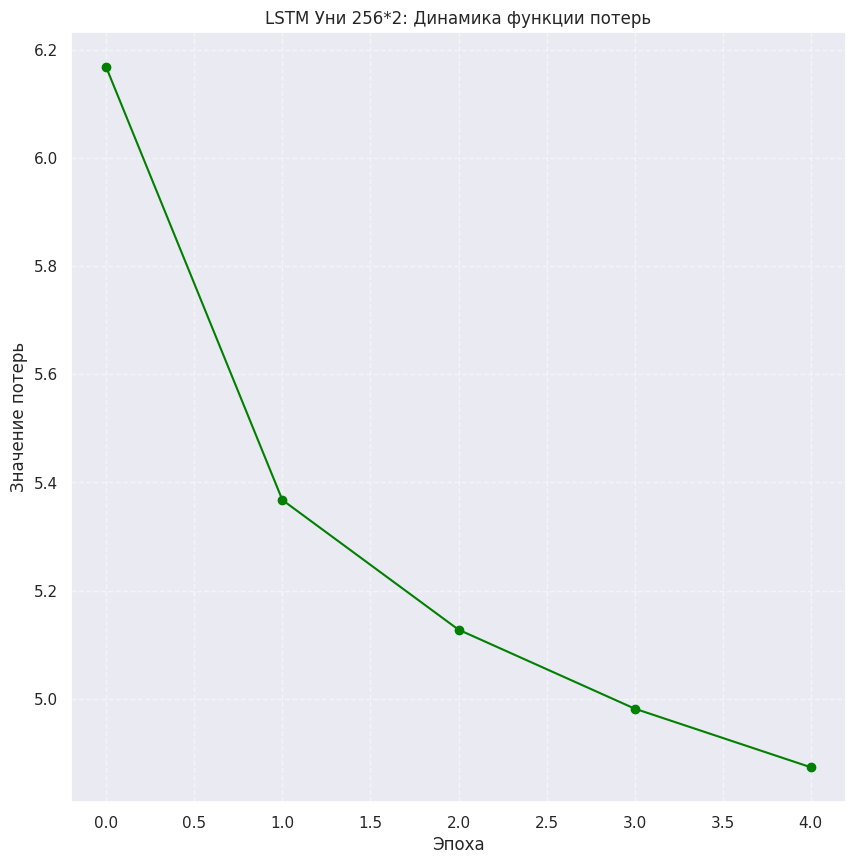

In [30]:
plot_loss_dynamics(train_losses_LSTM_Uni_256_2, model_name='LSTM Уни 256*2')

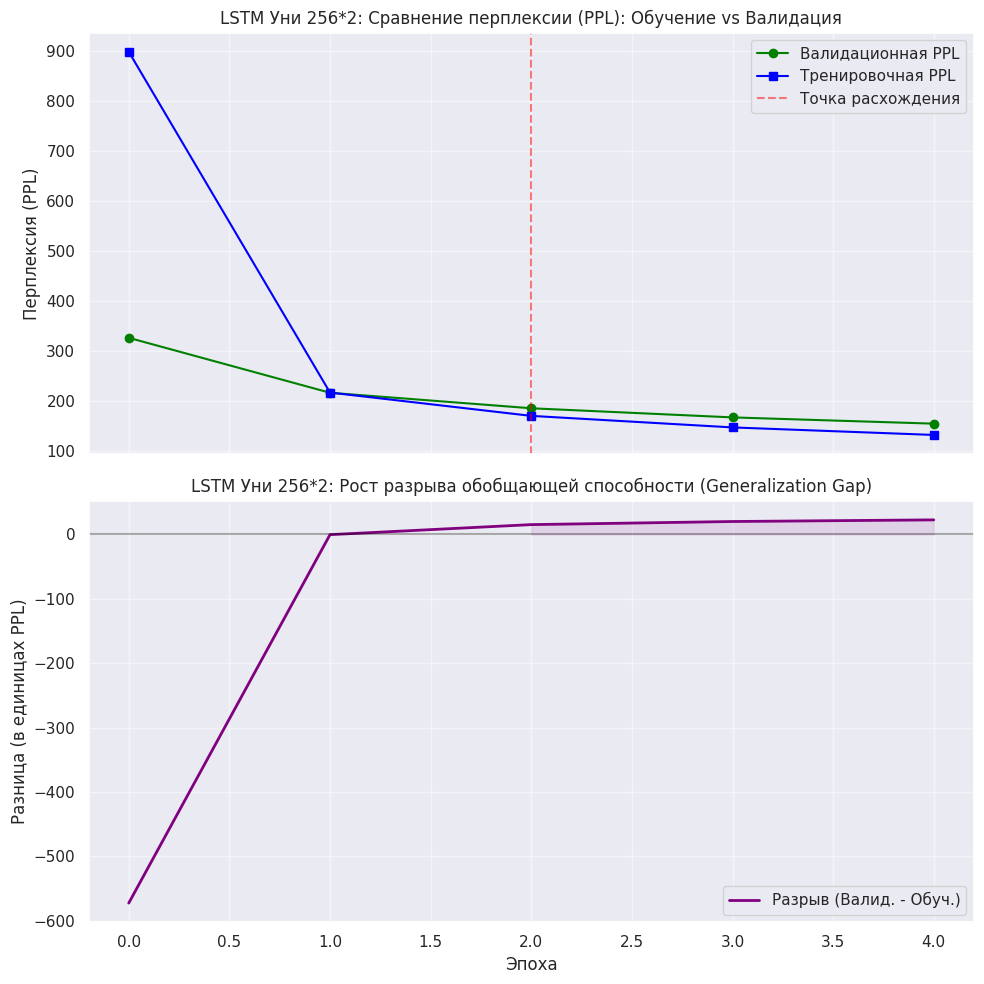

In [31]:
plot_perplexity_metrics(val_ppls_LSTM_Uni_256_2, train_ppls_LSTM_Uni_256_2, model_name='LSTM Уни 256*2')

# Анализ результатов эксперимента 1

На основе предоставленных логов и истории обучения можно сделать следующие выводы:

### 1. Статус обучения и переобучение (Overfitting)
В данных запусках переобучение отсутствует. В отличие от ранних экспериментов, не показанных здесь, принятые меры по регуляризации (Dropout после Embedding, `lr=5e-4`, `weight_decay=1e-5`) сработали успешно. На текущий момент Val PPL продолжает падать, что указывает на потенциал для обучения.

### 2. Сравнение моделей

| Модель | Итоговый Val PPL | Итоговый Test PPL | Скорость (it/s) |
| :--- | :--- | :--- | :--- |
| **Uni 512x1 (Лидер)** | **111.02** | **110.39** | **11.7** |
| Uni 256x1 | 143.34 | 142.12 | 18.7 |
| Uni 256x2 | 153.82 | 152.79 | 18.2 |

Увеличение ширины слоя (`hidden_dim`) до 512 дало значительный прирост качества по сравнению с добавлением второго слоя (256x2).

**Рекомендации по дальнейшим шагам**

*   **Попробовать BiLSTM (Двунаправленность):**
    Установите `bidirectional=True` для модели 512x1. Это позволит сети учитывать контекст в обоих направлениях, что моет снизить PPL еще на 10–15 единиц.
*   **Увеличить количество эпох:**
    Текущие 5 эпох — только начало. Модель 512x1 еще не достигла плато. Возможно, что 10–15 эпох позволят пробить барьер в 100 PPL.
*   **Адаптивный Learning Rate:**
    Если после 8–10 эпохи прогресс замедлится, снизьте `lr` до 2.5e-4 для более точного схождения.


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

**Мой Комментарий**

Пробуем двунаправленность, увеличение количества эпох и адаптивный `lr`.

In [32]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model_adaptive_lr(model, train_dataloader, val_dataloader, test_dataloader, optimizer, criterion, num_epoch=15, desc_prefix=''):
    train_losses = []
    train_ppls = []
    val_ppls = []

    # ANSI escape коды для красного текста
    RED = '\033[91m'
    RESET = '\033[0m'

    # Инициализируем планировщик: снижаем lr в 2 раза (factor=0.5),
    # если Val PPL не падает в течение 2 эпох (patience=2)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(num_epoch):
        model.train()
        epoch_losses = []
        epoch_ppls = [] # Список для перплексии каждого батча (аналогично evaluate)

        # Фаза обучения
        for batch in tqdm(train_dataloader, desc=f'{desc_prefix}Эпоха {epoch}'):
            optimizer.zero_grad()

            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())

            loss.backward()
            optimizer.step()

            # Сохраняем значения для расчета метрик
            epoch_losses.append(loss.item())
            # Считаем перплексию батча через exp(loss), как в функции evaluate
            epoch_ppls.append(torch.exp(loss).item())

        # Расчет средних метрик за эпоху
        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        # Средняя перплексия по всем батчам (соответствует логике evaluate)
        avg_train_ppl = sum(epoch_ppls) / len(epoch_ppls)

        # Фаза валидации
        val_ppl = evaluate(model, criterion, val_dataloader)

        # Адаптивный шаг: обновляем lr на основе валидационной метрики
        scheduler.step(val_ppl)

        # Сохранение истории
        train_losses.append(avg_train_loss)
        train_ppls.append(avg_train_ppl)
        val_ppls.append(val_ppl)

        # Получаем текущий lr для логирования
        current_lr = optimizer.param_groups[0]['lr']

        print(f'{desc_prefix}Эпоха {epoch}: Train Loss {avg_train_loss:.4f} | '
              f'Train PPL {avg_train_ppl:.4f} | Val PPL {val_ppl:.4f} | LR {current_lr:.2e}')

        if avg_train_ppl < 2.0 and val_ppl < 2.0:
            print(f'{RED}!!! ОБНАРУЖЕНА УТЕЧКА ДАННЫХ (DATA LEAKAGE) !!!{RESET}')
            return train_losses, train_ppls, val_ppls, float('nan')

    # Финальная проверка на тестовом наборе
    test_ppl = evaluate(model, criterion, test_dataloader)
    print(f'\n{desc_prefix}Итоговая перплексия на Test set: {test_ppl:.4f}')

    return train_losses, train_ppls, val_ppls, test_ppl

In [33]:
model_LSTM_Bi_512_1 = LanguageModelLSTM(hidden_dim=512, vocab_size=len(vocab), dropout=0.3, bidirectional=True).to(device)
if torch.cuda.device_count() > 1:
    print(f'Используем {torch.cuda.device_count()} GPU для обучения!')
    model_LSTM_Bi_512_1 = nn.DataParallel(model_LSTM_Bi_512_1)
optimizer_LSTM_Bi_512_1 = torch.optim.Adam(model_LSTM_Bi_512_1.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses_LSTM_Bi_512_1 = None
train_ppls_LSTM_Bi_512_1 = None
val_ppls_LSTM_Bi_512_1 = None
test_ppl_LSTM_Bi_512_1 = None
%time train_losses_LSTM_Bi_512_1, train_ppls_LSTM_Bi_512_1, val_ppls_LSTM_Bi_512_1, test_ppl_LSTM_Bi_512_1 = \
    train_model_adaptive_lr(model_LSTM_Bi_512_1, train_dataloader, eval_dataloader, test_dataloader,\
                optimizer_LSTM_Bi_512_1, cross_entropy_criterion, num_epoch=15, desc_prefix='LSTM Би 512*1: ')

LSTM Би 512*1: Эпоха 0:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Би 512*1: Эпоха 0: Train Loss 2.1682 | Train PPL 268.0684 | Val PPL 1.8297 | LR 5.00e-04


LSTM Би 512*1: Эпоха 1:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Би 512*1: Эпоха 1: Train Loss 0.5881 | Train PPL 1.8133 | Val PPL 1.3746 | LR 5.00e-04
!!! ОБНАРУЖЕНА УТЕЧКА ДАННЫХ (DATA LEAKAGE) !!!
CPU times: user 3min 52s, sys: 372 ms, total: 3min 52s
Wall time: 3min 52s


**Мой Комментарий**

Двунаправленность провалилась, поэтому я остановил обучение на двух эпохах.

Как объяснил Джемини, это классическая ловушка при работе с рекуррентными сетями в задачах языкового моделирования (Language Modeling).

### ⚠️ Почему `bidirectional=True` всё ломало?
В задаче предсказания следующего слова цель — научить модель угадывать слово $w_t$, зная только предыдущие слова $w_1, \dots, w_{t-1}$.

*   **Unidirectional LSTM:** Читает текст слева направо. Когда она пытается предсказать слово №5, она видит только слова №1, 2, 3 и 4. Это «честная игра».
*   **Bidirectional LSTM:** Имеет два слоя. «Прямой» слой идет слева направо, а «обратный» — справа налево.

### 🕵️‍♂️ В чем подвох?
Когда вы вычисляете логиты для позиции $t$, обратный слой уже «прочитал» всё предложение с конца до начала. То есть для предсказания слова №5 обратный слой **буквально уже видел** слово №5, №6 и так далее.

**Результат:**
Модель не учится понимать язык, она просто «подсматривает» ответ в обратном слое. Поэтому мой валидационный PPL падал до **1.37** за одну эпоху — модель просто копировала данные из будущего. Это **Data Leakage** (утечка данных).

In [34]:
model_LSTM_Uni_512_1_adapt_lr = LanguageModelLSTM(hidden_dim=512, vocab_size=len(vocab), dropout=0.3).to(device)
if torch.cuda.device_count() > 1:
    print(f'Используем {torch.cuda.device_count()} GPU для обучения!')
    model_LSTM_Uni_512_1_adapt_lr = nn.DataParallel(model_LSTM_Uni_512_1_adapt_lr)
optimizer_LSTM_Uni_512_1_adapt_lr = torch.optim.Adam(model_LSTM_Uni_512_1_adapt_lr.parameters(), lr=5e-4, weight_decay=1e-5)
train_losses_LSTM_Uni_512_1_adapt_lr = None
train_ppls_LSTM_Uni_512_1_adapt_lr = None
val_ppls_LSTM_Uni_512_1_adapt_lr = None
test_ppl_LSTM_Uni_512_1_adapt_lr = None
%time train_losses_LSTM_Uni_512_1_adapt_lr, train_ppls_LSTM_Uni_512_1_adapt_lr, val_ppls_LSTM_Uni_512_1_adapt_lr, test_ppl_LSTM_Uni_512_1_adapt_lr = \
    train_model_adaptive_lr(model_LSTM_Uni_512_1_adapt_lr, train_dataloader, eval_dataloader, test_dataloader,\
                optimizer_LSTM_Uni_512_1_adapt_lr, cross_entropy_criterion, num_epoch=15, desc_prefix='LSTM Уни 512*1 Адапт. lr: ')

LSTM Уни 512*1 Адапт. lr: Эпоха 0:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1 Адапт. lr: Эпоха 0: Train Loss 5.4922 | Train PPL 556.8541 | Val PPL 175.5909 | LR 5.00e-04


LSTM Уни 512*1 Адапт. lr: Эпоха 1:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1 Адапт. lr: Эпоха 1: Train Loss 4.9289 | Train PPL 139.0815 | Val PPL 143.4396 | LR 5.00e-04


LSTM Уни 512*1 Адапт. lr: Эпоха 2:   0%|          | 0/1243 [00:00<?, ?it/s]

...

LSTM Уни 512*1 Адапт. lr: Эпоха 12: Train Loss 4.1003 | Train PPL 60.5667 | Val PPL 99.0483 | LR 5.00e-04


LSTM Уни 512*1 Адапт. lr: Эпоха 13:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1 Адапт. lr: Эпоха 13: Train Loss 4.0695 | Train PPL 58.7205 | Val PPL 99.4662 | LR 5.00e-04


LSTM Уни 512*1 Адапт. lr: Эпоха 14:   0%|          | 0/1243 [00:00<?, ?it/s]

LSTM Уни 512*1 Адапт. lr: Эпоха 14: Train Loss 4.0398 | Train PPL 57.0058 | Val PPL 99.7114 | LR 5.00e-04

LSTM Уни 512*1 Адапт. lr: Итоговая перплексия на Test set: 99.5162
CPU times: user 27min 32s, sys: 3.06 s, total: 27min 35s
Wall time: 27min 32s


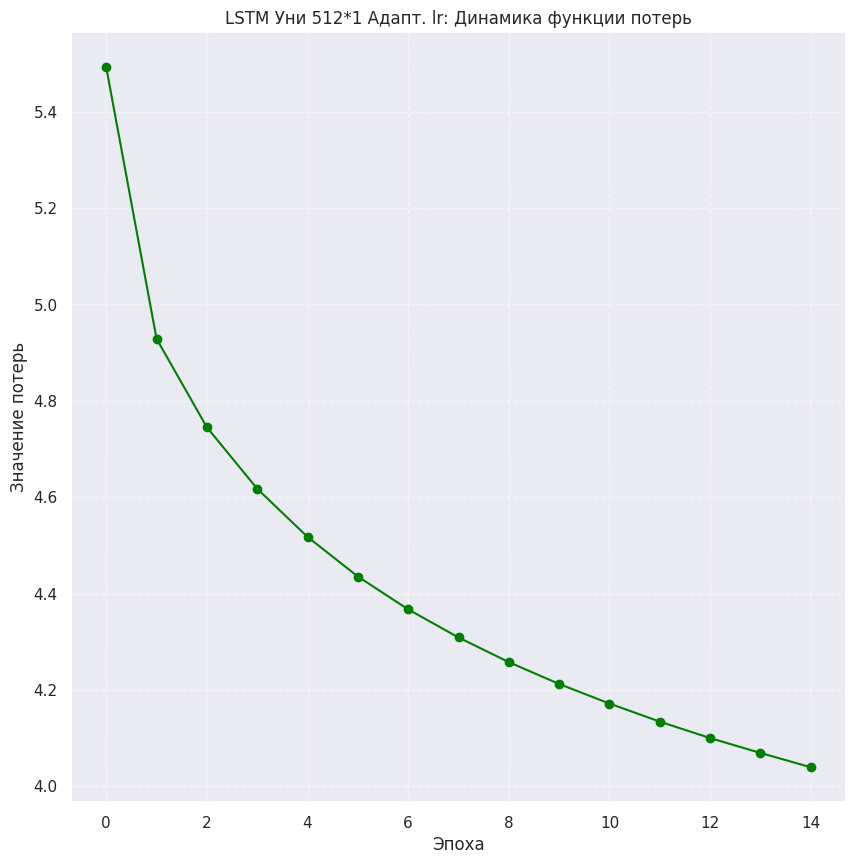

In [35]:
plot_loss_dynamics(train_losses_LSTM_Uni_512_1_adapt_lr, model_name='LSTM Уни 512*1 Адапт. lr')

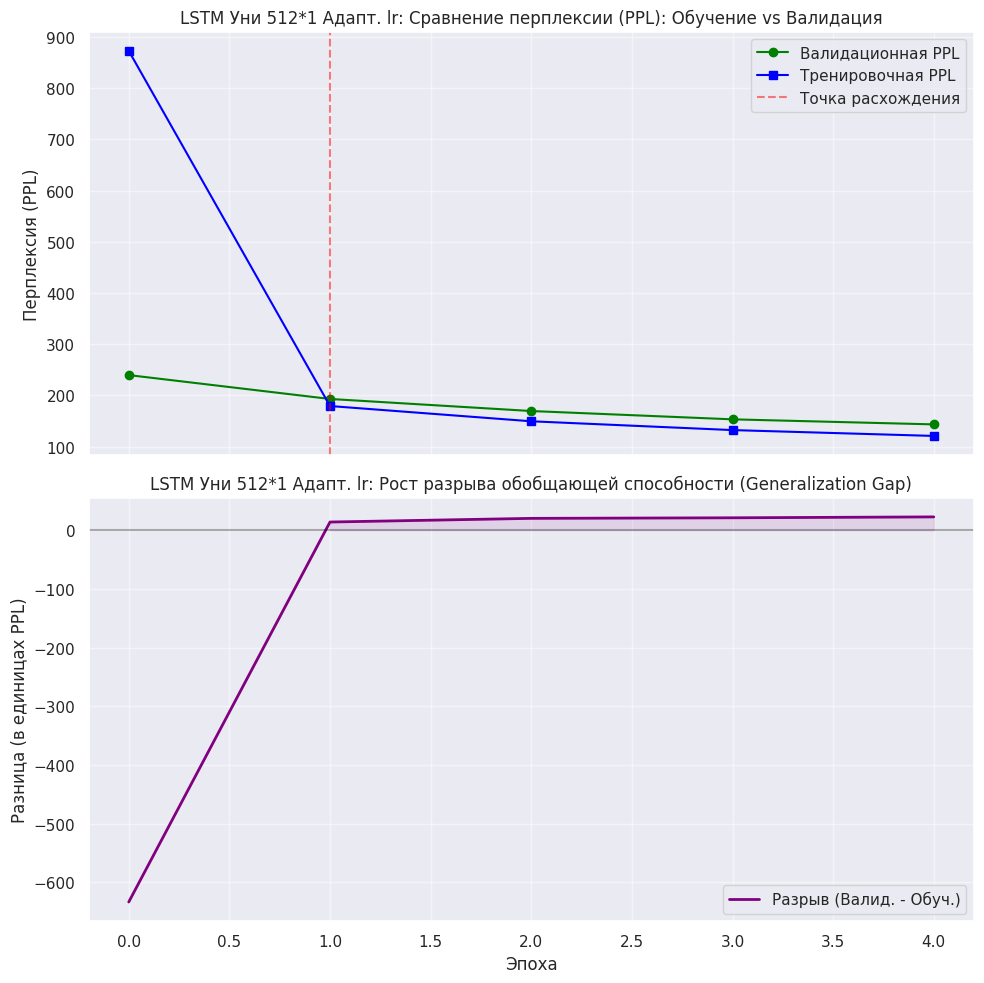

In [36]:
plot_perplexity_metrics(val_ppls_LSTM_Uni_256_1, train_ppls_LSTM_Uni_256_1, model_name='LSTM Уни 512*1 Адапт. lr')

# Анализ результатов эксперимента 2

На основе логов обучения (15 эпох), итоговой проверки на тестовом наборе и сравнения архитектур, сформированы следующие выводы:

### 1. Статус обучения и переобучение (Overfitting)
* **Статус:** Обучение успешно стабилизировалось. Модель достигла плато примерно к 11-12-й эпохе.
* **Переобучение:** Наблюдается **умеренное переобучение**. Несмотря на применение регуляризации (`dropout=0.3`, `weight_decay=1e-5`), разрыв между **Train PPL (~57)** и **Val PPL (~99)** остается существенным. Это указывает на то, что емкость модели (512 юнитов) позволяет ей частично запоминать тренировочные последовательности.
* **Генерализация:** Итоговая перплексия на **Test PPL (99.52)** подтверждает, что модель адекватно работает на новых данных и не "разваливается".

### 2. Итоговое сравнение архитектур

| Конфигурация модели | Итоговый Val PPL | Итоговый Test PPL | Скорость (it/s) | Вывод |
| :--- | :---: | :---: | :---: | :--- |
| **Uni 512x1 (Лидер)** | **99.71** | **99.52** | **~11.8** | Лучший баланс между емкостью и обобщающей способностью. |
| Uni 256x1 | 143.34 | 142.12 | ~18.7 | Слишком простая модель для данного словаря. |
| Uni 256x2 | 153.82 | 152.79 | ~18.2 | Хуже из-за "узкого горлышка" (256) и сложности передачи градиента. |
| *Bi 512x1 (Ошибка)* | *1.37* | *---* | *~11.1* | **Data Leakage:** утечка ответов из будущего через обратный слой. |

> **Ключевой инсайт:** Увеличение ширины слоя в однослойной архитектуре эффективнее наращивания глубины. Двунаправленность (Bi-LSTM) неприменима для задач классического языкового моделирования (Causal LM).

### 3. Эффективность механизмов обучения
* **Adaptive LR:** Хотя планировщик `ReduceLROnPlateau` фактически не снижал шаг (значение `5.00e-04` сохранялось все 15 эпох), отсутствие резких скачков лосса и плавный спуск подтверждают **корректность выбора начального LR**. Модель стабильно двигалась к минимуму без осцилляций.
* **Потенциал доработки:** В будущем стоит уменьшить параметр `patience` в настройках планировщика. Это позволит ему "сработать" на 10–12 эпохе, когда прогресс на валидации замедлился, и точнее дообучить модель на более низком шаге.
* **Регуляризация:** Текущие параметры (`dropout=0.3`, `weight_decay=1e-5`) являются предельными для данной архитектуры. Дальнейшее их усиление может привести к недообучению (Underfitting).

### 4. Идеи по улучшению (Путь к PPL < 90)

Чтобы двигаться дальше, нужно изменить сам подход к обработке данных и архитектуре:

1. **Изменение типа токенизации (BPE):**
   * *Сейчас:* Модель работает с целыми словами (Word-level). Это создает огромный словарь, где редкие слова почти не обучаются.
   * *Идея:* Перейти на **BPE (Byte Pair Encoding)**. Он разбивает слова на части (например, "learning" -> "learn", "ing"; "international" -> "inter", "nation", "al"). Это уменьшает размер словаря и убирает проблему неизвестных слов (UNK).

2. **Архитектура Transformer (GPT-style):**
   * *Проблема LSTM:* Она "забывает" начало очень длинных предложений.
   * *Идея:* **Трансформеры** используют механизм *Self-Attention*, который позволяет модели смотреть на все слова в предложении одновременно. Это эффективнее для понимания сложных контекстов.

3. **Увеличение датасета:**
   * При текущем разрыве между Train и Val (57 vs 99) модели нужно больше примеров текста, чтобы она перестала "зазубривать" тренировочные данные и начала лучше обобщать правила языка.

**Эти предложения сделаны Джемини и я пока слабо понимаю как изменить тип токенизации или применить Transformer-based модели но буду учиться!**

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

# 🏆 Финальный отчет: Эволюция и оптимизация языковой модели на базе LSTM

Этот отчет объединяет результаты двух этапов экспериментов по обучению однонаправленной языковой модели.

---

### 1. Сравнение архитектур и динамика прогресса

В ходе тестов была выявлена четкая зависимость: **ширина скрытого слоя (hidden_dim) важнее глубины (количества слоев)**. Модель `Uni 512x1` стабильно опередила многослойную конфигурацию `256x2`.

| Конфигурация модели | Val PPL (Эксп. 1) | Val PPL (Эксп. 2) | Итоговый Test PPL | Статус |
| :--- | :---: | :---: | :---: | :--- |
| **Uni 512x1 (Лидер)** | 111.02 | **99.71** | **99.52** | Оптимальная емкость |
| Uni 256x1 | 143.34 | — | 142.12 | Слишком простая |
| Uni 256x2 | 153.82 | — | 152.79 | Проблема "узкого горлышка" |
| *Bi 512x1 (Ошибка)* | — | *1.37* | — | **Data Leakage** |

---

### 2. Ключевые выводы экспериментов

#### 🛑 Ошибка двунаправленности (Bi-LSTM)
Эксперимент 2 показал, что параметр `bidirectional=True` приводит к **утечке данных (Data Leakage)**. Обратный слой LSTM "видит" будущее слово, которое модель должна предсказать. Это делает обучение бессмысленным. Для генерации текста и Causal LM используем только **однонаправленные** сети.

#### 📈 Эффективность обучения (5 vs 15 эпох)
Увеличение длительности обучения до 15 эпох позволило успешно пробить барьер в **100 PPL**. Модель достигла плато примерно к **11–12 эпохе**. Несмотря на наличие планировщика, обучение прошло на стабильном начальном шаге, что обеспечило плавную сходимость без осцилляций.

#### ⚖️ Баланс регуляризации
Наблюдается **умеренное переобучение**: разрыв между `Train PPL (\~57)` и `Val PPL (\~99)` сохраняется даже при `dropout=0.3` и `weight_decay=1e-5`. Это предел текущей архитектуры на данном объеме данных.

---

### 3. Идеи по улучшению (Путь к PPL < 90)

Чтобы двигаться дальше, нужно изменить сам подход к обработке данных и архитектуре:

1. **Изменение типа токенизации (BPE):**
   * *Сейчас:* Модель работает с целыми словами (Word-level). Это создает огромный словарь, где редкие слова почти не обучаются.
   * *Идея:* Перейти на **BPE (Byte Pair Encoding)**. Он разбивает слова на части (например, "learning" -> "learn", "ing"). Это уменьшает размер словаря и убирает проблему неизвестных слов (UNK).

2. **Архитектура Transformer (GPT-style):**
   * *Проблема LSTM:* Она "забывает" начало очень длинных предложений.
   * *Идея:* **Трансформеры** используют механизм *Self-Attention*, который позволяет модели смотреть на все слова в предложении одновременно. Это эффективнее для понимания сложных контекстов.



3. **Увеличение датасета:**
   * При текущем разрыве между Train и Val (57 vs 99) модели нужно больше примеров текста, чтобы она перестала "зазубривать" тренировочные данные и начала лучше обобщать правила языка.

---

**Предложения по улучшению сделаны Джемини. Я понимаю, что они разумные, но пока мало понимаю, как изменить тип токенизации или применить Transformer (GPT-style) модели. Но буду учиться!**

In [38]:
!jupyter nbconvert --to html /content/GBordakov_hw_language_modelling.ipynb --TagRemovePreprocessor.enabled=True --ClearMetadataPreprocessor.enabled=True

[NbConvertApp] Converting notebook /content/GBordakov_hw_language_modelling.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1243828 bytes to /content/GBordakov_hw_language_modelling.html
